# Assignment 3: CIFAR-10 Classification Using YOLO26

## Project Structure

1. Import the required libraries.
2. Load the CIFAR-10 dataset.
3. Randomly select and display 10 images.
4. Run baseline YOLO26 classification inference.
5. Compare predictions with ground-truth labels and calculate accuracy.
6. Fine-tune YOLO26 on CIFAR-10.
7. Evaluate the trained model on the test set.
8. Generate and analyze the multi-class confusion matrix.

## Step 1: Importing the Required Libraries

The required libraries are imported for loading CIFAR-10, performing YOLO26 classification, calculating accuracy, and displaying the results.

In [1]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.4 MB/s eta 0:00:00


In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torchvision.datasets import CIFAR10
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Step 2: Loading the CIFAR-10 Dataset

The CIFAR-10 test dataset is downloaded automatically. It contains images from 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

In [4]:
test_dataset = CIFAR10(
    root="/content/data",
    train=False,
    download=True
)

class_names = test_dataset.classes

print("Number of test images:", len(test_dataset))
print("Classes:", class_names)

100%|██████████| 170M/170M [17:31<00:00, 162kB/s]


Number of test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step 3: Random Image Sampling

Ten images are randomly selected from the CIFAR-10 test dataset. Their ground-truth labels are stored for comparison with the model predictions.

In [5]:
random.seed(42)

random_indices = random.sample(
    range(len(test_dataset)),
    10
)

sample_images = []
true_labels = []

for index in random_indices:
    image, label_id = test_dataset[index]

    sample_images.append(np.array(image))
    true_labels.append(class_names[label_id])

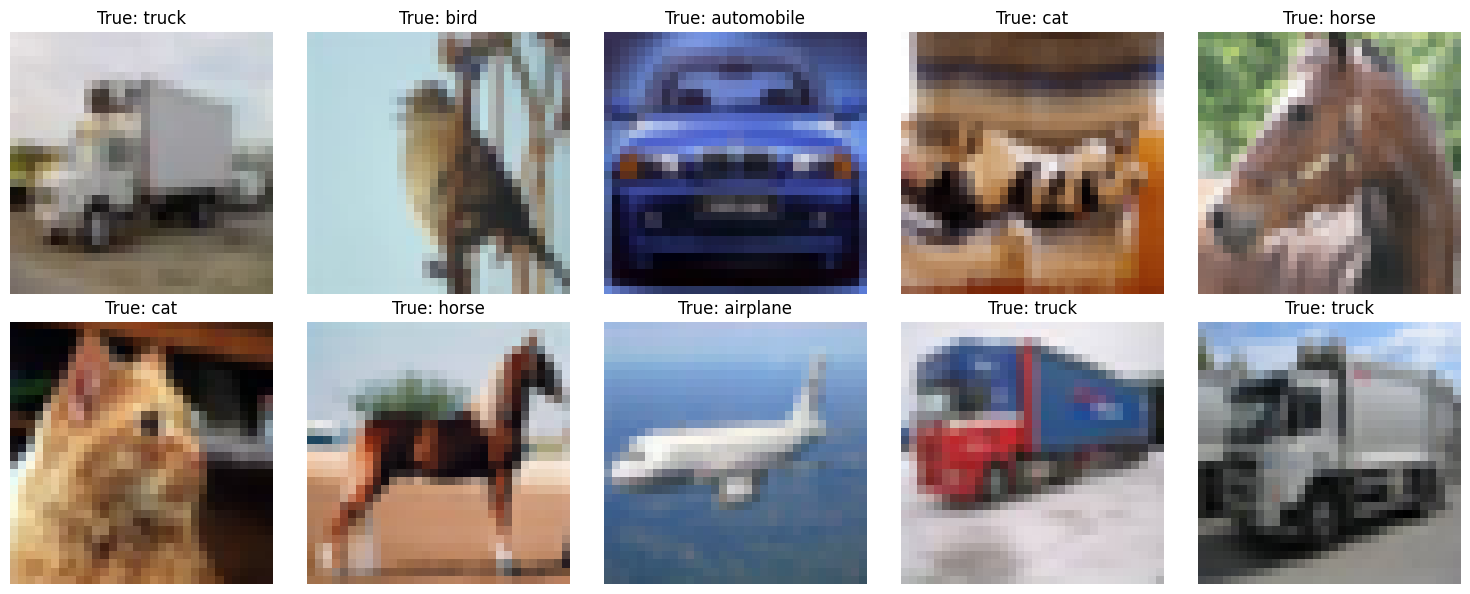

In [6]:
plt.figure(figsize=(15, 6))

for i, (image, label) in enumerate(
    zip(sample_images, true_labels)
):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(f"True: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 4: Baseline YOLO26 Inference

A pretrained YOLO26 classification model is used to classify the 10 randomly selected images. The top predicted class and confidence score are extracted for each image.

In [7]:
baseline_model = YOLO("yolo26n-cls.pt")

baseline_results = baseline_model.predict(
    source=sample_images,
    imgsz=224,
    verbose=False
)

predicted_labels = []
prediction_confidences = []

for result in baseline_results:
    predicted_id = result.probs.top1
    confidence = float(result.probs.top1conf)

    predicted_name = result.names[predicted_id]

    predicted_labels.append(predicted_name)
    prediction_confidences.append(confidence)

## Step 5: Baseline Accuracy Calculation

The predicted labels are compared with the CIFAR-10 ground-truth labels. Accuracy is calculated as the number of correct predictions divided by the total number of sampled images.

In [8]:
correct_predictions = 0

for i in range(10):
    is_correct = (
        predicted_labels[i].lower()
        == true_labels[i].lower()
    )

    if is_correct:
        correct_predictions += 1

    print(
        f"Image {i + 1}: "
        f"True = {true_labels[i]}, "
        f"Predicted = {predicted_labels[i]}, "
        f"Confidence = {prediction_confidences[i]:.2f}"
    )

baseline_accuracy = correct_predictions / 10

print(f"\nCorrect predictions: {correct_predictions}/10")
print(f"Baseline accuracy: {baseline_accuracy * 100:.2f}%")

Image 1: True = truck, Predicted = moving_van, Confidence = 0.88
Image 2: True = bird, Predicted = panpipe, Confidence = 0.37
Image 3: True = automobile, Predicted = cassette_player, Confidence = 0.77
Image 4: True = cat, Predicted = milk_can, Confidence = 0.66
Image 5: True = horse, Predicted = fox_squirrel, Confidence = 0.17
Image 6: True = cat, Predicted = Petri_dish, Confidence = 0.09
Image 7: True = horse, Predicted = cleaver, Confidence = 0.12
Image 8: True = airplane, Predicted = airliner, Confidence = 0.35
Image 9: True = truck, Predicted = moving_van, Confidence = 0.69
Image 10: True = truck, Predicted = moving_van, Confidence = 0.96

Correct predictions: 0/10
Baseline accuracy: 0.00%


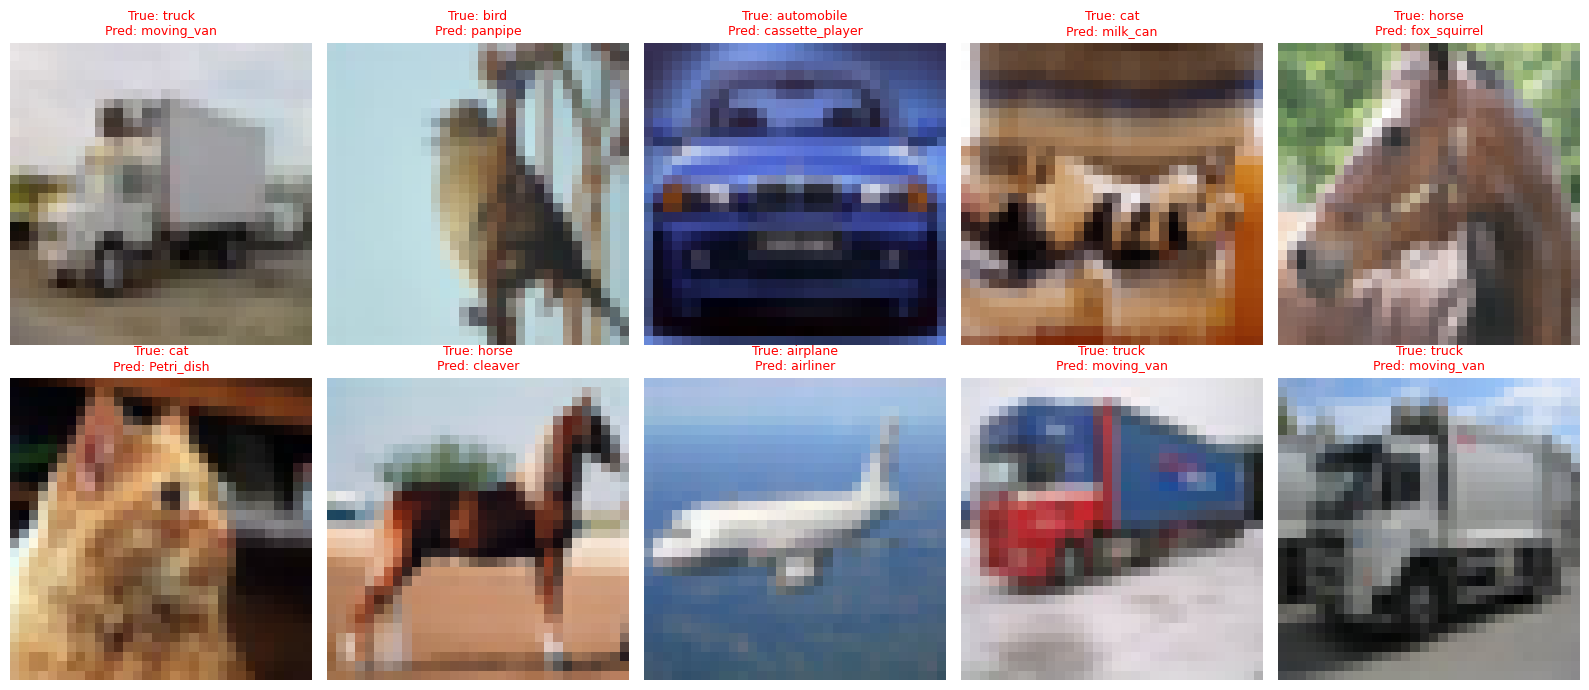

In [9]:
plt.figure(figsize=(16, 7))

for i, image in enumerate(sample_images):
    color = (
        "green"
        if predicted_labels[i].lower()
        == true_labels[i].lower()
        else "red"
    )

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)

    plt.title(
        f"True: {true_labels[i]}\n"
        f"Pred: {predicted_labels[i]}",
        color=color,
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
import torch

print("GPU is avaliable: ", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name: ", torch.cuda.get_device_name(0))

GPU is avaliable:  True
GPU name:  Tesla T4


## Step 6: Fine-Tuning YOLO26 on CIFAR-10

The pretrained YOLO26 classification model is fine-tuned on CIFAR-10. Fine-tuning adjusts the model weights and replaces the original ImageNet classification output with the 10 CIFAR-10 classes.

In [12]:
training_model = YOLO("yolo26n-cls.pt")

training_results = training_model.train(
    data="cifar10",
    epochs=30,
    imgsz=32,
    batch=64,
    project="runs/classify",
    name="cifar10_yolo26"
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cifar10, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=32, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cifar10_yolo26, nbs=64, nms=False, opset=None, opti

In [14]:
from pathlib import Path

best_models = list(Path("/content").rglob("best.pt"))

for path in best_models:
    print(path)

/content/runs/classify/runs/classify/cifar10_yolo26/weights/best.pt


## Step 7: Comprehensive Model Evaluation

The best trained model is loaded and evaluated on the CIFAR-10 test set. Top-1 accuracy measures how often the model's first prediction matches the correct class.

In [15]:
#Load the best model saved during training
trained_model = YOLO(
    "/content/runs/classify/runs/classify/cifar10_yolo26/weights/best.pt"
)

#Evaluate the trained model
metrics = trained_model.val(
    data="cifar10",
    imgsz=32,
    plots=True
)

print(f"Test Top-1 Accuracy: {metrics.top1 * 100:.2f}%")
print(f"Test Top-5 Accuracy: {metrics.top5 * 100:.2f}%")

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-cls summary (fused): 47 layers, 1,538,834 parameters, 0 gradients, 3.2 GFLOPs
WARNING ⚠️ Dataset 'split=val' not found, using 'split=test' instead.
train: /content/datasets/cifar10/train... found 50000 images in 10 classes ✅ 
val: /content/datasets/cifar10/test... found 10000 images in 10 classes ✅ 
test: /content/datasets/cifar10/test... found 10000 images in 10 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 120.2±53.6 MB/s, size: 1.9 KB)
val: Scanning /content/datasets/cifar10/test... 10000 images, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 3.5Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 625/625 75.1it/s 8.3s
                   all      0.824      0.992
Speed: 0.0ms preprocess, 0.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Test Top-1 Accuracy: 82.42%
Test Top-5 Accuracy: 99.19%


## Step 8: Multi-Class Confusion Matrix

A confusion matrix is generated to compare the true and predicted classes across all 10 CIFAR-10 categories. Values along the main diagonal represent correct predictions, while off-diagonal values represent classification errors.

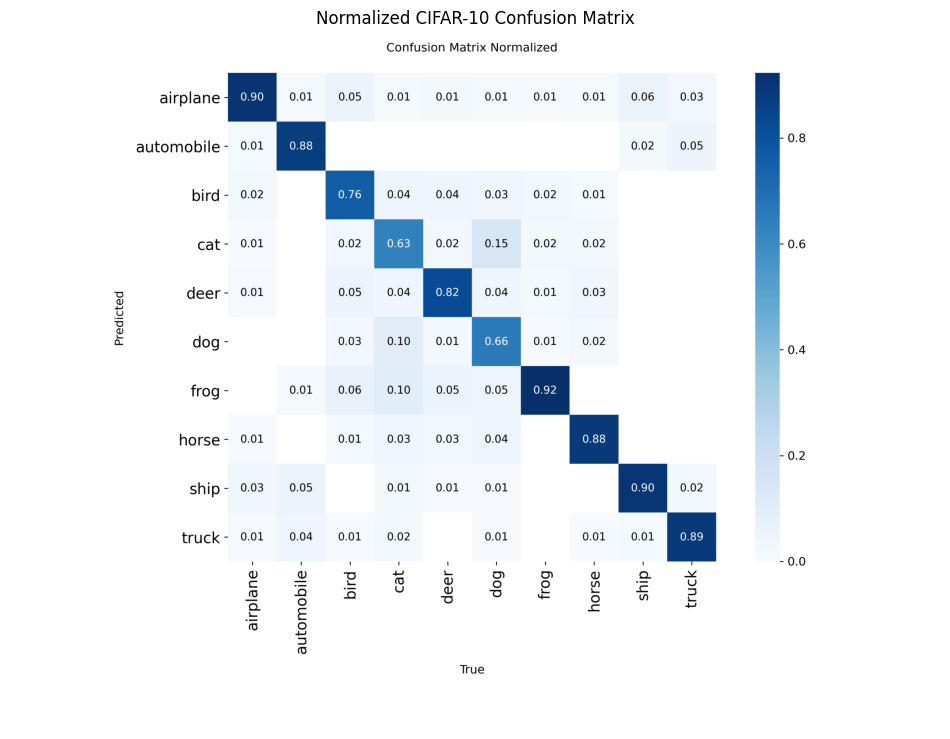

In [16]:
confusion_matrix_path = (
    Path(metrics.save_dir)
    / "confusion_matrix_normalized.png"
)

confusion_matrix_image = Image.open(
    confusion_matrix_path
)

plt.figure(figsize=(12, 10))
plt.imshow(confusion_matrix_image)
plt.axis("off")
plt.title("Normalized CIFAR-10 Confusion Matrix")
plt.show()

## Confusion Matrix Analysis

The confusion matrix shows the model's performance across the 10 CIFAR-10 classes. High values along the main diagonal indicate correct classifications. Values outside the diagonal represent classes that the model confused with one another. Similar-looking categories, such as cats and dogs or automobiles and trucks, may produce more classification errors. The trained model performs better than the baseline model because it was fine-tuned specifically on the CIFAR-10 classes.